# Traffic Project 2 — Modeling & Analysis

**Objective:** Build models that outperform persistence (y_t+1 = y_t) on:
- 1-step prediction (next hour)
- Multi-step prediction (next 6 hours)

**Models:**
1. Persistence Baseline
2. LSTM (adapted from Pt1 lecture notebook)
3. Transformer (adapted from Pt2 lecture notebook)
4. GCN + LSTM Hybrid (spatial-temporal)

**Explainability:** SHAP + Attention Weights (from Pt3 lecture notebook)

In [1]:
!rm -rf /content/traffic-project-2
!git clone https://github.com/dehiska/traffic-project-2.git
%cd traffic-project-2


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import gc

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


In [4]:
import os
from pathlib import Path

# Auto-detect: Colab (git clone) vs local Windows
if os.path.exists('/content/traffic-project-2'):
    PROJECT_DIR = Path('/content/traffic-project-2')  # Colab
else:
    PROJECT_DIR = Path("C:/Users/owner/Downloads/Masters/Masters_Spring_2026/Advanced Deep Learning/Traffic Project 2")  # Local

PROCESSED   = PROJECT_DIR / "processed"
MODEL_DIR   = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)


TARGET_YEAR = 2024  # Year to process
MAX_WEATHER_DIST_KM = 50   # Max distance to pair traffic<->weather stations
K_NEIGHBORS = 5            # K for KNN adjacency matrix
US_HOLIDAYS_2024 = [       # Federal holidays for feature engineering
    (1,1),(1,15),(2,19),(5,27),(6,19),(7,4),
    (9,2),(10,14),(11,11),(11,28),(12,25)
]

#Added this with chat
SEQ_LENGTH = 24        # or whatever you intended
FORECAST_H = 6         # (also used elsewhere)
BATCH_SIZE = 32        # (also referenced later)


---
## Load Processed Data

In [5]:
df = pd.read_csv(PROCESSED / f'ct_traffic_weather_{TARGET_YEAR}.csv', parse_dates=['timestamp'])
print(f"Loaded {len(df):,} rows, {df['station_id'].nunique()} stations")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
df.head()

Loaded 270,120 rows, 56 stations
Date range: 2024-01-02 00:00:00 -> 2024-12-31 23:00:00
Columns (30): ['station_id', 'timestamp', 'traffic_count', 'temp_c', 'dewpoint_c', 'wind_mph', 'precip_in', 'visibility_mi', 'is_raining', 'is_snowing', 'is_foggy', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'wind_gust', 'traffic_t-1', 'traffic_t-2', 'traffic_t-3', 'traffic_t-6', 'traffic_t-12', 'traffic_t-24', 'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_6h']


,station_id,timestamp,traffic_count,temp_c,dewpoint_c,wind_mph,precip_in,visibility_mi,is_raining,is_snowing,...,wind_gust,traffic_t-1,traffic_t-2,traffic_t-3,traffic_t-6,traffic_t-12,traffic_t-24,rolling_mean_6h,rolling_mean_24h,rolling_std_6h
0,9005,2024-03-02 00:00:00,76.0,3.333333,-3.333333,16.11092,0.0,10.0,0.0,0.0,...,0,103.0,128.0,147.0,349.0,405.00,43.0,155.333333,248.792917,77.906782
1,9005,2024-03-02 01:00:00,48.0,2.777778,-2.222222,9.20624,0.0,10.0,0.0,0.0,...,0,76.0,103.0,128.0,296.0,375.00,26.0,114.000000,249.709583,48.641546
2,9005,2024-03-02 02:00:00,42.0,2.777778,-2.222222,5.75390,0.0,10.0,0.0,0.0,...,0,48.0,76.0,103.0,182.0,462.00,14.0,90.666667,250.876250,42.716117
3,9005,2024-03-02 03:00:00,9.0,3.333333,-1.111111,9.20624,0.0,10.0,0.0,0.0,...,0,42.0,48.0,76.0,147.0,499.03,11.0,67.666667,250.792917,43.463395
4,9005,2024-03-02 04:00:00,22.0,3.888889,-0.555556,6.90468,0.0,10.0,0.0,0.0,...,0,9.0,42.0,48.0,128.0,466.00,19.0,50.000000,250.917917,34.692939


In [6]:
# Load adjacency matrix and station mapping for GCN
adj_matrix = np.load(PROCESSED / 'adj_matrix_knn.npy')
station_map = pd.read_csv(PROCESSED / 'station_node_mapping.csv')
station_to_idx = dict(zip(station_map['station_id'], station_map['node_idx']))
n_nodes = len(station_map)
print(f"Graph: {n_nodes} nodes, {(adj_matrix > 0).sum()} edges")

Graph: 56 nodes, 202 edges


---
## Data Preprocessing

In [7]:
# Define feature columns and target
target_col = 'traffic_count'

exclude_cols = ['station_id', 'timestamp', 'traffic_count']
feature_cols = [c for c in df.columns if c not in exclude_cols
                and df[c].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f"Target: {target_col}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Target: traffic_count
Features (27): ['temp_c', 'dewpoint_c', 'wind_mph', 'precip_in', 'visibility_mi', 'is_raining', 'is_snowing', 'is_foggy', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday', 'wind_gust', 'traffic_t-1', 'traffic_t-2', 'traffic_t-3', 'traffic_t-6', 'traffic_t-12', 'traffic_t-24', 'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_6h']


In [8]:
# ── Train / Test Split (time-based: first 80% / last 20%) ──
# Use a single representative station first for LSTM/Transformer,
# then expand to all stations for GCN

# Pick the station with the most data
station_counts = df.groupby('station_id').size().sort_values(ascending=False)
primary_station = station_counts.index[0]
print(f"Primary station: {primary_station} ({station_counts.iloc[0]:,} records)")

df_single = df[df['station_id'] == primary_station].sort_values('timestamp').reset_index(drop=True)
df_single = df_single.dropna(subset=feature_cols + [target_col])

split_idx = int(len(df_single) * 0.8)
train_df = df_single.iloc[:split_idx].copy()
test_df  = df_single.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows ({train_df['timestamp'].min()} -> {train_df['timestamp'].max()})")
print(f"Test:  {len(test_df):,}  rows ({test_df['timestamp'].min()} -> {test_df['timestamp'].max()})")

Primary station: 9073 (8,688 records)
Train: 6,782 rows (2024-01-02 00:00:00 -> 2024-10-21 03:00:00)
Test:  1,696  rows (2024-10-21 04:00:00 -> 2024-12-30 23:00:00)


In [9]:
# ── Scaling ──
scaler_x = StandardScaler()
scaler_y = StandardScaler()

train_x_scaled = scaler_x.fit_transform(train_df[feature_cols])
train_y_scaled = scaler_y.fit_transform(train_df[[target_col]])

test_x_scaled = scaler_x.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

print(f"Scaled X shape: {train_x_scaled.shape}")
print(f"Scaled y shape: {train_y_scaled.shape}")

Scaled X shape: (6782, 27)
Scaled y shape: (6782, 1)


In [10]:
# ── Sequence Creation (from lecture Pt1/Pt2) ──
def create_sequences(features, target, seq_length):
    """Create sliding window sequences for time series."""
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

def create_sequences_multistep(features, target, seq_length, horizon):
    """Create sequences for multi-step prediction."""
    X, y = [], []
    for i in range(len(features) - seq_length - horizon + 1):
        X.append(features[i:i+seq_length])
        y.append(target[i+seq_length:i+seq_length+horizon].flatten())
    return np.array(X), np.array(y)

# 1-step sequences
X_train_1s, y_train_1s = create_sequences(train_x_scaled, train_y_scaled, SEQ_LENGTH)
X_test_1s,  y_test_1s  = create_sequences(test_x_scaled,  test_y_scaled,  SEQ_LENGTH)

# Multi-step sequences
X_train_ms, y_train_ms = create_sequences_multistep(train_x_scaled, train_y_scaled, SEQ_LENGTH, FORECAST_H)
X_test_ms,  y_test_ms  = create_sequences_multistep(test_x_scaled,  test_y_scaled,  SEQ_LENGTH, FORECAST_H)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_1s, dtype=torch.float32)
y_train = torch.tensor(y_train_1s, dtype=torch.float32)
X_test  = torch.tensor(X_test_1s,  dtype=torch.float32)
y_test  = torch.tensor(y_test_1s,  dtype=torch.float32)

X_train_m = torch.tensor(X_train_ms, dtype=torch.float32)
y_train_m = torch.tensor(y_train_ms, dtype=torch.float32)
X_test_m  = torch.tensor(X_test_ms,  dtype=torch.float32)
y_test_m  = torch.tensor(y_test_ms,  dtype=torch.float32)

print(f"1-step  -> X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"           X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Multi-step -> X_train: {X_train_m.shape}, y_train: {y_train_m.shape}")
print(f"             X_test:  {X_test_m.shape},  y_test:  {y_test_m.shape}")

1-step  -> X_train: torch.Size([6758, 24, 27]), y_train: torch.Size([6758, 1])
           X_test:  torch.Size([1672, 24, 27]),  y_test:  torch.Size([1672, 1])
Multi-step -> X_train: torch.Size([6753, 24, 27]), y_train: torch.Size([6753, 6])
             X_test:  torch.Size([1667, 24, 27]),  y_test:  torch.Size([1667, 6])


---
## Persistence Baseline

The simplest model: predict the next hour's traffic as equal to the current hour.

In [11]:
def print_metrics(true, pred, label):
    """Print RMSE, MAE, MAPE, R2 for a model."""
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    # Avoid division by zero for MAPE
    mask = true != 0
    mape = np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100
    r2   = r2_score(true, pred)
    print(f"{label:20s} -> RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | MAPE: {mape:5.2f}% | R2: {r2:.4f}")
    return {'model': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# ── 1-Step Persistence ──
# y_naive(t+1) = y(t) — shift actual target by 1
y_test_naive = torch.cat([y_test[0:1], y_test[:-1]])
y_test_true_inv  = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()
y_test_naive_inv = scaler_y.inverse_transform(y_test_naive.numpy().reshape(-1, 1)).flatten()

results = []
results.append(print_metrics(y_test_true_inv, y_test_naive_inv, 'Persistence (1-step)'))

# ── Multi-Step Persistence ──
# For h-step: predict each of the next h hours as equal to the last known value
y_test_m_true_inv = scaler_y.inverse_transform(y_test_m.numpy())
y_test_m_naive = y_test_m_true_inv[:, 0:1].repeat(FORECAST_H, axis=1)  # repeat last known

# Evaluate multi-step persistence per horizon
for h in range(FORECAST_H):
    rmse_h = np.sqrt(mean_squared_error(y_test_m_true_inv[:, h], y_test_m_naive[:, h]))
    print(f"  Persistence t+{h+1}: RMSE = {rmse_h:.2f}")

Persistence (1-step) -> RMSE:   133.41 | MAE:    93.46 | MAPE: 28.39% | R2: 0.8009
  Persistence t+1: RMSE = 0.00
  Persistence t+2: RMSE = 133.59
  Persistence t+3: RMSE = 227.51
  Persistence t+4: RMSE = 297.09
  Persistence t+5: RMSE = 348.38
  Persistence t+6: RMSE = 389.07


---
## Model 1 — LSTM

Adapted from lecture Pt1 (`DemandLSTM`).  
Architecture: LSTM(64) → LSTM(32) → Dense(1)

In [12]:
class TrafficLSTM(nn.Module):
    """LSTM for traffic prediction (adapted from DemandLSTM in Pt1 notebook)."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1):
        super(TrafficLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # last time step
        return out

In [13]:
import time

EPOCHS = 50
PATIENCE = 7
LEARNING_RATE = 0.01
BATCH_SIZE = 32

def train_model(model, X_train, y_train, X_test, y_test,
                epochs=EPOCHS, patience=PATIENCE, lr=LEARNING_RATE,
                model_name='model'):
    """Generic training loop with early stopping and per-epoch progress."""
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test, y_test),
                              batch_size=BATCH_SIZE, shuffle=False)

    best_test_loss = float('inf')
    counter = 0
    train_losses, test_losses = [], []
    model_path = str(MODEL_DIR / f'best_{model_name}.pth')

    n_train = len(train_loader)
    n_test  = len(test_loader)
    print(f"\n{'='*70}")
    print(f"Training {model_name}  |  {epochs} max epochs, patience={patience}, lr={lr}")
    print(f"  Train: {len(X_train)} samples ({n_train} batches)  |  Test: {len(X_test)} samples ({n_test} batches)")
    print(f"  Batch size: {BATCH_SIZE}  |  Device: {device}")
    print(f"{'='*70}")
    t_start = time.time()

    for epoch in range(epochs):
        t_ep = time.time()

        # Train
        model.train()
        batch_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        # Validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                val_losses.append(criterion(outputs, batch_y).item())
        test_loss = np.mean(val_losses)
        test_losses.append(test_loss)

        ep_time = time.time() - t_ep
        marker = ''

        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            counter = 0
            torch.save(model.state_dict(), model_path)
            marker = ' << best'
        else:
            counter += 1

        print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_losses[-1]:.6f} | Test: {test_loss:.6f} | "
              f"{ep_time:.1f}s | patience {counter}/{patience}{marker}")

        if counter >= patience:
            elapsed = time.time() - t_start
            print(f"\n  Early stopping at epoch {epoch+1}  (total: {elapsed:.0f}s)")
            break

    # Load best model
    model.load_state_dict(torch.load(model_path, weights_only=True))
    total = time.time() - t_start
    print(f"  Done! Best test loss: {best_test_loss:.6f}  |  Total: {total:.0f}s\n")
    return train_losses, test_losses


In [14]:
# ── Train LSTM ──
lstm_model = TrafficLSTM(input_dim=X_train.shape[2], hidden_dim=64, num_layers=2)
lstm_train_loss, lstm_test_loss = train_model(
    lstm_model, X_train, y_train, X_test, y_test, model_name='traffic_lstm'
)

Training traffic_lstm...
  Early stopping at epoch 11
  Best test loss: 0.044725


In [15]:
# ── Evaluate LSTM ──
def get_predictions(model, X, device):
    """Get chronological predictions (no shuffle)."""
    model.eval()
    loader = DataLoader(TensorDataset(X, torch.zeros(len(X), 1)),
                        batch_size=BATCH_SIZE, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            preds.append(model(batch_X.to(device)).cpu().numpy())
    return np.vstack(preds)

lstm_preds_scaled = get_predictions(lstm_model, X_test, device)
lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled).flatten()

results.append(print_metrics(y_test_true_inv, lstm_preds, 'LSTM (1-step)'))

LSTM (1-step)        -> RMSE:    67.93 | MAE:    47.46 | MAPE: 16.10% | R2: 0.9484


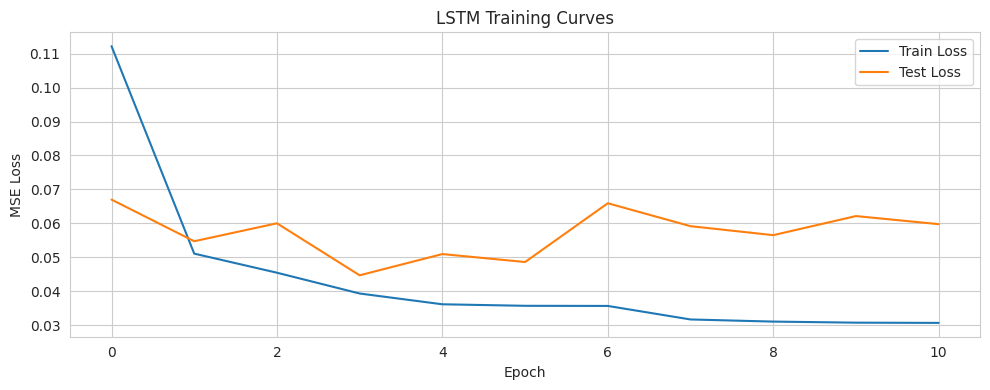

In [16]:
# ── LSTM Training Curves ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_train_loss, label='Train Loss')
ax.plot(lstm_test_loss, label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

---
## Model 2 — Transformer

Adapted from lecture Pt2 (`DemandTransformer`).  
Architecture: Linear projection → Positional Encoding → TransformerEncoder → Dense(1)

In [17]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (from Pt2 notebook)."""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TrafficTransformer(nn.Module):
    """Transformer encoder for traffic prediction (adapted from DemandTransformer)."""
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, output_dim=1):
        super(TrafficTransformer, self).__init__()
        self.encoder_input_layer = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_layers=num_layers
        )
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.encoder_input_layer(x)   # [B, 24, d_model]
        x = self.pos_encoder(x)
        out = self.transformer_encoder(x)  # [B, 24, d_model]
        out = self.decoder(out[:, -1, :])  # last time step -> [B, output_dim]
        return out

In [18]:
# ── Train Transformer ──
torch.cuda.empty_cache()
gc.collect()

transformer_model = TrafficTransformer(
    input_dim=X_train.shape[2], d_model=64, nhead=4, num_layers=2
)
tf_train_loss, tf_test_loss = train_model(
    transformer_model, X_train, y_train, X_test, y_test,
    lr=0.0005, patience=12, model_name='traffic_transformer'
)

Training traffic_transformer...
  Epoch 20/50 | Train: 0.027061 | Test: 0.041222
  Early stopping at epoch 29
  Best test loss: 0.039403


In [19]:
# ── Evaluate Transformer ──
tf_preds_scaled = get_predictions(transformer_model, X_test, device)
tf_preds = scaler_y.inverse_transform(tf_preds_scaled).flatten()

results.append(print_metrics(y_test_true_inv, tf_preds, 'Transformer (1-step)'))

Transformer (1-step) -> RMSE:    63.36 | MAE:    43.95 | MAPE: 14.80% | R2: 0.9551


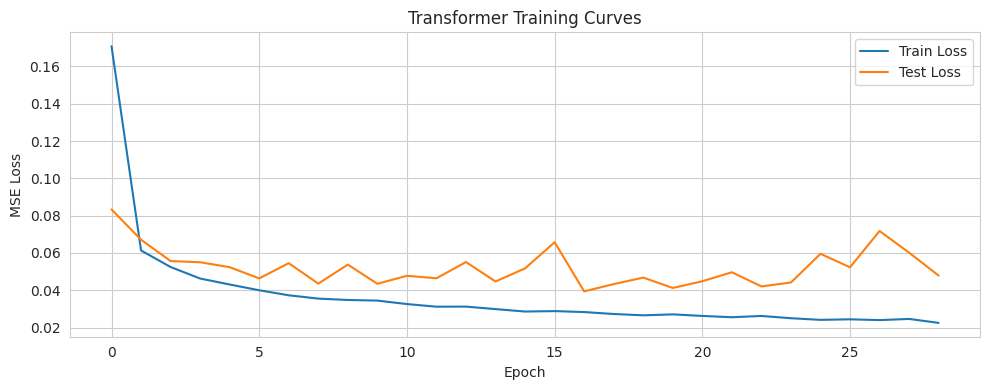

In [20]:
# ── Transformer Training Curves ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tf_train_loss, label='Train Loss')
ax.plot(tf_test_loss, label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Transformer Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

---
## Model 3 — GCN + LSTM Hybrid

Combines spatial dependencies (GCN on the station graph) with temporal modeling (LSTM).  
Requires `torch_geometric`. If not installed: `pip install torch-geometric`

In [21]:
!pip install torch_geometric

In [22]:
try:
    from torch_geometric.nn import GCNConv
    from torch_geometric.utils import dense_to_sparse
    HAS_PYG = True
    print("torch_geometric available")
except ImportError:
    HAS_PYG = False
    print("torch_geometric not installed. Install with: pip install torch-geometric")
    print("Falling back to a simple spatial-aware LSTM (no GCN).")

torch_geometric available


In [23]:
# ── Prepare multi-station data for GCN ──
# We need all stations aligned to the same timestamps
valid_stations = sorted(df['station_id'].unique())
valid_stations = [s for s in valid_stations if s in station_to_idx]
n_graph_nodes = len(valid_stations)
print(f"Stations for GCN: {n_graph_nodes}")

# Pivot: each timestamp gets a row, each station's features become columns
# For GCN we use a simpler feature set to keep memory manageable
gcn_features = ['traffic_count', 'temp_c', 'wind_mph', 'precip_in',
                 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']
gcn_features = [c for c in gcn_features if c in df.columns]

# Build a 3D tensor: [timestamps, nodes, features]
all_timestamps = sorted(df['timestamp'].unique())
print(f"Total unique timestamps: {len(all_timestamps)}")

# Create node-indexed data
node_data = {}
for sid in valid_stations:
    sdf = df[df['station_id'] == sid].set_index('timestamp')[gcn_features]
    sdf = sdf.reindex(all_timestamps)
    sdf = sdf.ffill(limit=3).bfill(limit=3)  # fill small gaps
    node_data[sid] = sdf.values

# Stack into [T, N, F]
graph_data = np.stack([node_data[sid] for sid in valid_stations], axis=1)
graph_data = np.nan_to_num(graph_data, nan=0.0)
print(f"Graph data shape: {graph_data.shape}  (T, N, F)")

Stations for GCN: 56
Total unique timestamps: 8760
Graph data shape: (8760, 56, 9)  (T, N, F)


In [24]:
# ── Scale graph data ──
T, N, F = graph_data.shape
graph_flat = graph_data.reshape(-1, F)
scaler_graph_x = StandardScaler()

split_t = int(T * 0.8)
scaler_graph_x.fit(graph_flat[:split_t * N])
graph_scaled = scaler_graph_x.transform(graph_flat).reshape(T, N, F)

# Target is the traffic_count (index 0 in gcn_features)
target_idx = gcn_features.index('traffic_count')

# Create sequences for GCN-LSTM: input [SEQ, N, F], target [N, 1]
def create_graph_sequences(data, seq_len, target_feat_idx):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])       # [seq_len, N, F]
        y.append(data[i+seq_len, :, target_feat_idx])  # [N]
    return np.array(X), np.array(y)

gX, gy = create_graph_sequences(graph_scaled, SEQ_LENGTH, target_idx)
g_split = int(len(gX) * 0.8)

gX_train = torch.tensor(gX[:g_split], dtype=torch.float32)
gy_train = torch.tensor(gy[:g_split], dtype=torch.float32)
gX_test  = torch.tensor(gX[g_split:], dtype=torch.float32)
gy_test  = torch.tensor(gy[g_split:], dtype=torch.float32)

print(f"GCN-LSTM X_train: {gX_train.shape}, y_train: {gy_train.shape}")
print(f"GCN-LSTM X_test:  {gX_test.shape},  y_test:  {gy_test.shape}")

GCN-LSTM X_train: torch.Size([6988, 24, 56, 9]), y_train: torch.Size([6988, 56])
GCN-LSTM X_test:  torch.Size([1748, 24, 56, 9]),  y_test:  torch.Size([1748, 56])


In [25]:
if HAS_PYG:
    # Build edge index from adjacency matrix
    node_idxs = [station_to_idx[s] for s in valid_stations if s in station_to_idx]
    adj_sub = adj_matrix[np.ix_(node_idxs, node_idxs)]
    adj_tensor = torch.tensor(adj_sub, dtype=torch.float32)
    edge_index, edge_weight = dense_to_sparse(adj_tensor)
    edge_index = edge_index.to(device)
    edge_weight = edge_weight.to(device)
    N_nodes = adj_sub.shape[0]
    print(f"Edge index shape: {edge_index.shape}, Edge weight shape: {edge_weight.shape}")

    def build_batch_edge_index(edge_index, edge_weight, batch_size, n_nodes):
        """Replicate a single graph's edges for B independent copies in one mega-graph."""
        offsets = torch.arange(batch_size, device=edge_index.device) * n_nodes
        ei = edge_index.unsqueeze(2) + offsets.view(1, 1, -1)  # [2, E, B]
        ei = ei.permute(0, 2, 1).reshape(2, -1)                # [2, B*E]
        ew = edge_weight.repeat(batch_size)                     # [B*E]
        return ei, ew

    class GCN_LSTM(nn.Module):
        """GCN for spatial features + LSTM for temporal — VECTORIZED for GPU."""
        def __init__(self, in_features, gcn_hidden=32, lstm_hidden=32, n_nodes=1):
            super(GCN_LSTM, self).__init__()
            self.gcn1 = GCNConv(in_features, gcn_hidden)
            self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)
            self.relu = nn.ReLU()
            self.lstm = nn.LSTM(gcn_hidden, lstm_hidden, num_layers=1, batch_first=True)
            self.fc = nn.Linear(lstm_hidden, 1)
            self.n_nodes = n_nodes
            self._edge_cache = {}

        def _get_batch_edges(self, edge_index, edge_weight, B):
            if B not in self._edge_cache:
                self._edge_cache[B] = build_batch_edge_index(
                    edge_index, edge_weight, B, self.n_nodes)
            return self._edge_cache[B]

        def forward(self, x, edge_index, edge_weight):
            # x: [B, T, N, F]
            B, T, N, F_in = x.shape

            # Vectorized GCN: all B graphs processed at once per timestep
            batch_ei, batch_ew = self._get_batch_edges(edge_index, edge_weight, B)
            gcn_steps = []
            for t in range(T):
                xt = x[:, t, :, :].reshape(B * N, F_in)  # [B*N, F]
                h = self.relu(self.gcn1(xt, batch_ei, batch_ew))
                h = self.relu(self.gcn2(h, batch_ei, batch_ew))
                gcn_steps.append(h.view(B, N, -1))
            gcn_out = torch.stack(gcn_steps, dim=1)  # [B, T, N, gcn_hidden]

            # Vectorized LSTM: all nodes in one call
            gcn_flat = gcn_out.permute(0, 2, 1, 3).reshape(B * N, T, -1)  # [B*N, T, H]
            lstm_out, _ = self.lstm(gcn_flat)
            out = self.fc(lstm_out[:, -1, :])  # [B*N, 1]
            return out.view(B, N)

    print(f"GCN_LSTM model defined (VECTORIZED, {N_nodes} nodes).")
    print(f"  Old: 24*B per-sample GCN calls + N per-node LSTM calls (slow on GPU)")
    print(f"  New: 24 batched GCN calls + 1 LSTM call (fast on GPU)")
else:
    print("Skipping GCN_LSTM (torch_geometric not available).")


Edge index shape: torch.Size([2, 202]), Edge weight shape: torch.Size([202])
GCN_LSTM model defined.


In [ ]:
if HAS_PYG:
    # ── Train GCN-LSTM ──
    torch.cuda.empty_cache()
    gc.collect()

    gcn_lstm_model = GCN_LSTM(in_features=F, gcn_hidden=32, lstm_hidden=32, n_nodes=N_nodes).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(gcn_lstm_model.parameters(), lr=0.001)

    gcn_batch_size = 16
    train_loader_g = DataLoader(TensorDataset(gX_train, gy_train),
                                batch_size=gcn_batch_size, shuffle=True)
    test_loader_g  = DataLoader(TensorDataset(gX_test, gy_test),
                                batch_size=gcn_batch_size, shuffle=False)

    n_train_b = len(train_loader_g)
    n_test_b  = len(test_loader_g)

    print(f"\n{'='*70}")
    print(f"Training GCN-LSTM  |  {EPOCHS} max epochs, patience={PATIENCE}")
    print(f"  Train: {len(gX_train)} samples ({n_train_b} batches)  |  Test: {len(gX_test)} samples ({n_test_b} batches)")
    print(f"  Batch size: {gcn_batch_size}  |  Device: {device}")
    print(f"{'='*70}")

    best_loss = float('inf')
    counter = 0
    gcn_train_losses, gcn_test_losses = [], []
    t_start = time.time()

    for epoch in range(EPOCHS):
        t_ep = time.time()

        gcn_lstm_model.train()
        batch_losses = []
        for i, (bX, by) in enumerate(train_loader_g):
            bX, by = bX.to(device), by.to(device)
            optimizer.zero_grad()
            out = gcn_lstm_model(bX, edge_index, edge_weight)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            # Show batch progress on first epoch
            if epoch == 0 and n_train_b > 10 and (i + 1) % max(1, n_train_b // 4) == 0:
                print(f"    [epoch 1] batch {i+1}/{n_train_b}  loss={loss.item():.6f}")
        gcn_train_losses.append(np.mean(batch_losses))

        # Validate
        gcn_lstm_model.eval()
        val_losses = []
        with torch.no_grad():
            for bX, by in test_loader_g:
                bX, by = bX.to(device), by.to(device)
                out = gcn_lstm_model(bX, edge_index, edge_weight)
                val_losses.append(criterion(out, by).item())
        test_loss = np.mean(val_losses)
        gcn_test_losses.append(test_loss)

        ep_time = time.time() - t_ep
        marker = ''

        if test_loss < best_loss:
            best_loss = test_loss
            counter = 0
            torch.save(gcn_lstm_model.state_dict(), str(MODEL_DIR / 'best_gcn_lstm.pth'))
            marker = ' << best'
        else:
            counter += 1

        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | Train: {gcn_train_losses[-1]:.6f} | Test: {test_loss:.6f} | "
              f"{ep_time:.1f}s | patience {counter}/{PATIENCE}{marker}")

        if counter >= PATIENCE:
            elapsed = time.time() - t_start
            print(f"\n  Early stopping at epoch {epoch+1}  (total: {elapsed:.0f}s)")
            break

    gcn_lstm_model.load_state_dict(
        torch.load(str(MODEL_DIR / 'best_gcn_lstm.pth'), weights_only=True)
    )
    total = time.time() - t_start
    print(f"  Done! Best test loss: {best_loss:.6f}  |  Total: {total:.0f}s\n")


Training GCN-LSTM...


In [ ]:
if HAS_PYG:
    # ── Evaluate GCN-LSTM ──
    print("Evaluating GCN-LSTM on test set...")
    t0 = time.time()
    gcn_lstm_model.eval()
    all_preds = []
    all_true  = []
    with torch.no_grad():
        for i, (bX, by) in enumerate(test_loader_g):
            bX = bX.to(device)
            out = gcn_lstm_model(bX, edge_index, edge_weight)
            all_preds.append(out.cpu().numpy())
            all_true.append(by.numpy())
            if (i + 1) % max(1, len(test_loader_g) // 4) == 0:
                print(f"  Eval batch {i+1}/{len(test_loader_g)}")

    gcn_preds = np.vstack(all_preds)  # [samples, N]
    gcn_true  = np.vstack(all_true)
    print(f"  Inference done in {time.time()-t0:.1f}s  |  Predictions shape: {gcn_preds.shape}")

    # Inverse transform
    mean_t = scaler_graph_x.mean_[target_idx]
    std_t  = scaler_graph_x.scale_[target_idx]
    gcn_preds_inv = gcn_preds * std_t + mean_t
    gcn_true_inv  = gcn_true  * std_t + mean_t

    # Overall metrics across all nodes
    results.append(print_metrics(
        gcn_true_inv.flatten(), gcn_preds_inv.flatten(), 'GCN+LSTM (all nodes)'
    ))

    # Per-node metrics for the primary station
    if primary_station in valid_stations:
        pidx = valid_stations.index(primary_station)
        results.append(print_metrics(
            gcn_true_inv[:, pidx], gcn_preds_inv[:, pidx], 'GCN+LSTM (primary)'
        ))


---
## Multi-Step Prediction (LSTM & Transformer)

In [ ]:
# ── Multi-step LSTM ──
lstm_ms = TrafficLSTM(input_dim=X_train_m.shape[2], hidden_dim=64,
                       num_layers=2, output_dim=FORECAST_H)
lstm_ms_train, lstm_ms_test = train_model(
    lstm_ms, X_train_m, y_train_m, X_test_m, y_test_m,
    model_name='traffic_lstm_multistep'
)

lstm_ms_preds = get_predictions(lstm_ms, X_test_m, device)
lstm_ms_preds_inv = scaler_y.inverse_transform(lstm_ms_preds)

print("\nMulti-step LSTM results per horizon:")
for h in range(FORECAST_H):
    rmse_h = np.sqrt(mean_squared_error(y_test_m_true_inv[:, h], lstm_ms_preds_inv[:, h]))
    print(f"  LSTM t+{h+1}: RMSE = {rmse_h:.2f}")

In [ ]:
# ── Multi-step Transformer ──
torch.cuda.empty_cache()
gc.collect()

tf_ms = TrafficTransformer(input_dim=X_train_m.shape[2], d_model=64,
                            nhead=4, num_layers=2, output_dim=FORECAST_H)
tf_ms_train, tf_ms_test = train_model(
    tf_ms, X_train_m, y_train_m, X_test_m, y_test_m,
    lr=0.0005, patience=12, model_name='traffic_transformer_multistep'
)

tf_ms_preds = get_predictions(tf_ms, X_test_m, device)
tf_ms_preds_inv = scaler_y.inverse_transform(tf_ms_preds)

print("\nMulti-step Transformer results per horizon:")
for h in range(FORECAST_H):
    rmse_h = np.sqrt(mean_squared_error(y_test_m_true_inv[:, h], tf_ms_preds_inv[:, h]))
    print(f"  Transformer t+{h+1}: RMSE = {rmse_h:.2f}")

---
## Model Comparison

In [ ]:
# ── Comparison Table ──
results_df = pd.DataFrame(results)
persistence_rmse = results_df[results_df['model'].str.contains('Persistence')]['RMSE'].values[0]
results_df['Beats Persistence?'] = results_df['RMSE'] < persistence_rmse

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

In [ ]:
# ── Comparison Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['gray', 'steelblue', 'coral', 'green', 'purple'][:len(results_df)]

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(results_df['model'], results_df[metric], color=colors)
    ax.set_title(metric, fontsize=14)
    ax.tick_params(axis='x', rotation=30)
    # Add value labels
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison (1-Step)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Residual Plots: True vs Predicted ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_to_plot = [
    ('Persistence', y_test_naive_inv),
    ('LSTM', lstm_preds),
    ('Transformer', tf_preds),
]

for ax, (name, preds) in zip(axes, models_to_plot):
    ax.scatter(y_test_true_inv, preds, alpha=0.3, s=5)
    lims = [min(y_test_true_inv.min(), preds.min()),
            max(y_test_true_inv.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(PROCESSED / 'residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Error Analysis by Hour and Weather ──
# Get hour/weather info aligned with test predictions
test_meta = test_df.iloc[SEQ_LENGTH:].reset_index(drop=True)
test_meta = test_meta.iloc[:len(lstm_preds)].copy()

test_meta['lstm_error'] = np.abs(y_test_true_inv[:len(test_meta)] - lstm_preds[:len(test_meta)])
test_meta['tf_error']   = np.abs(y_test_true_inv[:len(test_meta)] - tf_preds[:len(test_meta)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Error by hour
hourly_err = test_meta.groupby('hour')[['lstm_error', 'tf_error']].mean()
hourly_err.plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MAE')
axes[0].legend(['LSTM', 'Transformer'])

# Error by weather
if 'is_raining' in test_meta.columns:
    weather_err = test_meta.groupby('is_raining')[['lstm_error', 'tf_error']].mean()
    weather_err.index = ['Clear', 'Rain']
    weather_err.plot(kind='bar', ax=axes[1])
    axes[1].set_title('MAE by Weather Condition')
    axes[1].set_ylabel('MAE')
    axes[1].legend(['LSTM', 'Transformer'])

plt.tight_layout()
plt.savefig(PROCESSED / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Time Series Plot: Sample Week ──
n_plot = 168  # 1 week
fig, ax = plt.subplots(figsize=(16, 5))
x_axis = range(n_plot)

ax.plot(x_axis, y_test_true_inv[:n_plot], 'k-', linewidth=1.5, label='Actual', alpha=0.8)
ax.plot(x_axis, y_test_naive_inv[:n_plot], '--', color='gray', label='Persistence', alpha=0.6)
ax.plot(x_axis, lstm_preds[:n_plot], '-', color='steelblue', label='LSTM', alpha=0.7)
ax.plot(x_axis, tf_preds[:n_plot], '-', color='coral', label='Transformer', alpha=0.7)

ax.set_xlabel('Hours')
ax.set_ylabel('Traffic Count')
ax.set_title('1-Week Forecast Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / 'forecast_sample_week.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Explainability (adapted from Pt3 notebook)

- **Transformer Attention Weights:** Which timesteps does the model focus on?
- **SHAP:** Which features drive predictions?

In [ ]:
# ── Transformer Attention Weights ──
# Extract attention from the transformer encoder
transformer_model.eval()

# We need to manually pass through the layers to capture attention
sample_X = X_test[:100].to(device)

with torch.no_grad():
    # Project features
    x = transformer_model.encoder_input_layer(sample_X)
    x = transformer_model.pos_encoder(x)

    # Get attention from first encoder layer
    enc_layer = transformer_model.transformer_encoder.layers[0]
    # Self-attention
    attn_output, attn_weights = enc_layer.self_attn(
        x, x, x, need_weights=True, average_attn_weights=True
    )

attn_matrix = attn_weights.cpu().numpy().mean(axis=0)  # average over samples
print(f"Attention matrix shape: {attn_matrix.shape}")

# Plot temporal attention
lag_labels = [f"-{24-i}h" for i in range(24)]

plt.figure(figsize=(12, 9))
sns.heatmap(attn_matrix, cmap='magma',
            xticklabels=lag_labels, yticklabels=lag_labels)
plt.title('Temporal Attention: Which Lags Matter Most?', fontsize=14, fontweight='bold')
plt.xlabel("Historical Lag (Evidence)", fontsize=12)
plt.ylabel("Target Lag (Query)", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / 'attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Attention: Which hours get the most attention? ──
# Sum attention received by each time step (column sums)
attn_importance = attn_matrix.sum(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lag_labels, attn_importance, color='darkred')
ax.set_xlabel('Historical Lag')
ax.set_ylabel('Total Attention Received')
ax.set_title('Temporal Importance: How Much Attention Each Lag Receives')
plt.tight_layout()
plt.savefig(PROCESSED / 'attention_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP Analysis ──
try:
    import shap

    # Wrap model for SHAP (flattened input)
    transformer_model.eval()
    n_features = X_test.shape[2]

    def model_predict(flat_input):
        """SHAP-compatible prediction function."""
        x = torch.tensor(flat_input, dtype=torch.float32).reshape(-1, SEQ_LENGTH, n_features)
        with torch.no_grad():
            return transformer_model(x.to(device)).cpu().numpy()

    # Use a background sample for SHAP
    background = X_test[:50].numpy().reshape(50, -1)
    test_sample = X_test[50:150].numpy().reshape(100, -1)

    explainer = shap.KernelExplainer(model_predict, background)
    print("Computing SHAP values (this may take several minutes)...")
    shap_values = explainer.shap_values(test_sample, nsamples=100)

    # Reshape SHAP values back to [samples, timesteps, features]
    shap_reshaped = np.array(shap_values).reshape(-1, SEQ_LENGTH, n_features)

    # Average absolute SHAP over time steps to get feature importance
    feature_importance = np.abs(shap_reshaped).mean(axis=(0, 1))
    feat_imp_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': feature_importance
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='teal')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Feature Importance (Transformer - SHAP)')
    plt.tight_layout()
    plt.savefig(PROCESSED / 'shap_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Temporal SHAP: which time steps matter most?
    temporal_importance = np.abs(shap_reshaped).mean(axis=(0, 2))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(lag_labels, temporal_importance, color='darkorange')
    ax.set_xlabel('Historical Lag')
    ax.set_ylabel('Mean |SHAP value|')
    ax.set_title('Temporal Importance (SHAP): Which Hours Drive Predictions?')
    plt.tight_layout()
    plt.savefig(PROCESSED / 'shap_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print("Install SHAP for explainability: pip install shap")

In [ ]:
# ── Spatial Error Map (if GCN was trained) ──
if HAS_PYG:
    node_mae = np.abs(gcn_true_inv - gcn_preds_inv).mean(axis=0)
    spatial_df = station_map.copy()
    spatial_df = spatial_df.iloc[:len(node_mae)]
    spatial_df['mae'] = node_mae

    try:
        import folium
        from folium.plugins import HeatMap

        m = folium.Map(location=[41.6, -72.7], zoom_start=9)
        for _, row in spatial_df.iterrows():
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=max(3, row['mae'] / node_mae.max() * 15),
                color='red', fill=True, fill_opacity=0.7,
                popup=f"Station: {row['station_id']}\nMAE: {row['mae']:.1f}"
            ).add_to(m)
        m.save(str(PROCESSED / 'spatial_error_map.html'))
        print("Saved spatial error map to processed/spatial_error_map.html")
        display(m)
    except ImportError:
        fig, ax = plt.subplots(figsize=(10, 8))
        sc = ax.scatter(spatial_df['longitude'], spatial_df['latitude'],
                        c=spatial_df['mae'], cmap='YlOrRd', s=80)
        plt.colorbar(sc, label='MAE')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Spatial MAE by Station (GCN+LSTM)')
        plt.tight_layout()
        plt.savefig(PROCESSED / 'spatial_error_map.png', dpi=150, bbox_inches='tight')
        plt.show()

---
## Summary

In [ ]:
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)

print("\nKey Findings:")
best_model = results_df.loc[results_df['RMSE'].idxmin()]
print(f"  Best model: {best_model['model']} (RMSE: {best_model['RMSE']:.2f})")

for _, row in results_df.iterrows():
    if row['model'] != 'Persistence (1-step)':
        improvement = (persistence_rmse - row['RMSE']) / persistence_rmse * 100
        status = 'BEATS' if row['Beats Persistence?'] else 'LOSES TO'
        print(f"  {row['model']:25s} {status} persistence by {abs(improvement):.1f}%")

print("\nSaved outputs:")
for f in sorted(PROCESSED.iterdir()):
    print(f"  {f.name}")